# Optimización de Rutas Logísticas: Implementación de Arbol-KD
**Cristian Álvarez Cuartas**
**Estructuras de Datos**

##1. **Introducción**

Este proyecto implementa un Árbol de Búsqueda K-Dimensional (KD-Tree), una estructura de datos de partición espacial que organiza puntos en un espacio $k$-dimensional. El objetivo es reducir la complejidad de búsqueda a $O(\log N)$, permitiendo:
1. **Búsqueda por Radio:** Encontrar todos los puntos dentro de una distancia $r$.
2. **Vecino más Cercano (NN):** Localizar el punto más próximo a una coordenada dada.

## **Conceptualización: Arbol KD**

Un arbol KD es una estructura de datos de la familia de árboles, que organiza sus nodos con base a la distancia espacial entre cada uno de ellos. Su funcionamiento consiste en la división consecutiva del espacio:
**1. División por mediana**:Se selecciona una dimensión y se calcula la mediana de los puntos ordenando por esa dimensión. Esta mediana define un punto de corte (hiperplano de corte) que divide los datos en dos subconjuntos: Los puntos a la izquierda del hiperplano y los puntos a la derecha del hiperplano.

El proceso utiliza recursión: Si en el primer nivel se divide por mediana en el eje x, en el segundo nivel se subdividirá por mediana en el eje y, ý así sucesivamente con las k dimensiones de los puntos, repitiendo cada ciclo hasta que haya una mediana asociada a cada punto.

De esta manera, cada nodo del árbol no representa únicamente un punto, sino una subdivisión o frontera espacial que nos sirve para descartar regiones durante una búsqueda, optimizando demasiado el rendimiento.

---

#PROBLEMA
Eres parte de un equipo que desarrolla un sistema de logistica de entregas en una ciudad.
Tienes coordenadas (x,y) de 10.000 puntos de entrega (estos datos los puedes tomar de datos reales
o generarlos, para este ejercicio los datos son estaticos, es decir, no cambian).

Necesitas implementar un sistema que responda eficientemente preguntas como:
* ¿que puntos de entrega estan a un radio de 500 metros de un punto dado? (tener en cuenta unidades)
* ¿cual es el puntos de entrega mas cercano a una ubicacion dada?

El objetivo del laboratorio es analizar cómo es el rendimiento de búsqueda para una distancia espacial en estructuras normales o de "Fuerza bruta" como en listas simples o arrays, comparado con la búsqueda dentro de un KDTree.

---

## 2. Implementación del Algoritmo KD-Tree
El sistema se componene de la siguiente estructura de clases de python:

**Clase Nodo**: Almacena las coordenadas del punto, la dimensión que corta y la conexión con sus hijos izquierdo o derecho ("o arriba y abajo")

**Clase ArbolKD**: Contiene la lógica de construcción del árbol, junto con los algoritmos de búsqueda asociados (Punto más cercano y vecinos por radio).

### Funciones Principales:
* `construir()`: Método recursivo que genera el árbol balanceado.

* `buscarMasCercano()`: Filtra sobre qué ramas no debe ir comparando la distancia al plano de corte con la mejor distancia hallada:

$$\text{distancia_eje} = |objetivo_{eje} - nodo_{eje}|$$
Si esta distancia al eje es menor que la mejor distancia encontrada hasta el momento, significa que existe la posibilidad de que haya un punto aún más cercano en la región opuesta. Solo en ese caso, el algoritmo decide explorar el otro. Es decir, buscamos por regiones intuitivamente: si encontramos que la distancia entre el objetivo y el eje es menor que la menor distancia encontrada en esa region, significa que quizá al otro lado del eje puede haber un punto más cercano. Así sucesivamente.


* `buscarPorRadio()`: Se van recorriendo nodos, empezando desde la raiz, comparando si la distancia euclidiana entre el objetivo y el nodo en que estamos parados es menor o igual al radio, para saber si se incluye en la lista de nodos cercanos. Decidimos si vale la pena entrar a buscar dentro de otra partición de eje o no, comparando la distancia entre el objetivo y dicho eje divisorio. Si la distancia es menor al radio, significa que al otro lado de la "rayita" pueden haber puntos que entran dentro del radio, y por tanto debería ir a ese lado. Si no entran dentro del radio, simplemente no se hace búsqueda en ese lado opuesto.


---

#**IMPLEMENTACIÓN PYTHON**

Es importante mencionar que para el CALCULO DEL CENTRO DE MASA, o DE LA MEDIANA, organizamos los datos con base al eje que vayamos a cortar (x, y,...n). Y seleccionamos el dato que hay en su mitad. De esta forma, se garantiza que no se selecciona la mitad del rango del eje k, sino que se escoge el que hay en MEDIO de la distribución. Aquel punto que, no necesariamente es la mitad del rango k, pero que a su izquierda y derecha tiene la misma cantidad de puntos. Funciona como una mitad para la dispersión, no para el rango. Despues de ordenarlo, se garantiza que el punto en la mitad del arreglo separa a la izquierda de él al mismo número de datos que a la derecha de él.

In [ ]:
"""FUNCION calcularCentroMasa():
recibe como parametro la lista de puntos, y la dimension sobre la cual se calculara la mediana.
Su retorno sera el punto de la mediana, y el indice donde se encuentra dicho punto.
"""

def calcularCentroMasa(lista, dimension): #Se calcula el centro de masa (que para el caso se hara con la mediana de los puntos dados como en las diapositivas)
    lista.sort(key=lambda x: x[dimension]) #Se ordena la lista en orden ascendente, teniendo en cuenta el eje dimension. Si dimension es 0, se organiza la lista con base a las componentes del eje x, y asi sucesivamente.
    indice_mediana = len(lista) // 2 #Se halla el indice de la mediana
    punto_mediana = lista[indice_mediana] #Con el indice anterior, se encuentra la mediana como punto
    return punto_mediana, indice_mediana #Retornamos el punto de la mediana y el indice donde encontramos dicho punto (para fines practicos)


"""FUNCION calcularDistancia(): recibe como parametros los puntos entre los que se quiere hallar la distancia.
Simplemente calcula la distancia euclidiana para cualquier dimension, restando entre componentes, elevando al cuadrado dicha resta, sumando el resultado anterior, y sacando la raiz cuadrada del resultado.
El retorno es la distancia calculada.

"""
def calcularDistancia(punto1, punto2):


    if not(len(punto1)==len(punto2)):
        print("Puntos en diferente dimension. No operable (si es operable pero no lo considero para el caso)") #Si bien podriamos mapear aquellos que sean de una dimension menos, en el origen de la dimension que les falta, para el caso no los consideramos.
        return
    resta = [] #Guardamos la resta por componentes
    for i in range (0, len(punto1)):
        resta.append(punto1[i]-punto2[i]) #Se agrega en la lista la resta de cada componente (xi-yi)
    distancia = 0 #Acumulador de la resta de las distancias al cuadrado
    for i in resta:
        distancia += i**2 # (xi - yi)**2
    distancia = distancia**0.5 #Raiz cuadrada del acumulador anterior.
    return distancia



class Nodo:
    def __init__(self, punto, dimension_corte): #Punto seria el punto en el plano n dimensional, y dimension_corte seria el indicador de, si estamos dividiendo por mediana de x, o por mediana de xi)
        self.punto = punto
        self.dimension_corte = dimension_corte #Dimension en la que está. Si está al lado derecho-izquierdo de la mediana de x, o al lado arriba-abajo de la mediana de y.
        self.izquierdo = None #Al bajar de nivel entonces estaríamos cambiando de dimension, es decir, ya estamos hablando del eje y, o de la siguiente dimension
        self.derecho = None #Al bajar de nivel entonces estaríamos cambiando de dimension, es decir, ya estamos hablando del eje y, o de la siguiente dimension.
class ArbolKD:
    def __init__(self, puntos):
        self.raiz = self.construir(puntos, 0)



    """FUNCION construir(): recibe como parametro la lista de puntos, y la profundidad del arbol o nivel en que está (cuando se creao siempre se está en nivel 0).
    Cada que se crea un subarbol izquierdo o derecho, se baja del nivel y por tanto cambia la profundidad en la que estamos parados. Siempre se inicia parado en el nivel 0, es decir cuando la partición se hace en el eje x.
    En el nivel 1, se hace la partición en el eje y, y así sucesivamente con n dimensiones. Como en este caso solo hay dimension 0, cuando esté en una dimensión par está particionando en el eje x, ý cuando está en dimensión
    impar se particiona en el eje y. Se crean recursivamente subárboles, y se van conectando con sus padres, hasta que el nodo que se devuelva es el nodo raiz, que está conectado con todos los hijos (los subárboles)
    """


    def construir(self, lista_puntos, profundidad):
        if len(lista_puntos)==0:
            return None
        numDimensiones = len(lista_puntos[0]) #Para saber el numero de dimensiones que tienen los puntos, y ademas usarlos como un tipo de enum: 1 seria dim x, 2 seria dim y, 3 seria dim z, ..., .
        dimensionActual = profundidad%numDimensiones  #Se calcula la dimension en la que estamos parados, si estamos en los datos a izquierda o derecha de la mediana x, o arriba-abajo de la mediana y.
        """dimensiondActual nos dice en que nivel del arbol estamos. Empieza en 0, porque al ingresar el nodo raiz, el arbol tiene profundidad 0. Al aplicarle modulo a la profundidad del arbol actual, conocemos
        de que eje estamos hablando. Si el modulo es 0, entonces estamos hablando del eje x, si es 1, del eje y, y asi sucesivamente
        """
        punto_raiz, indice_raiz = calcularCentroMasa(lista_puntos, dimensionActual) #Calculamos cual es el nodo raiz o la primera division por mitad que se hace
        nodo_raiz = Nodo(punto_raiz, dimensionActual) #Se crea el nodo raiz con la mediana del eje x (Dimension_actual dice en qué lugar estamos sacando la mediana)
        nodo_raiz.izquierdo = self.construir(lista_puntos[:indice_raiz], profundidad+1) #Se construye el subarbol izquierdo (por la izquierda de la mediana en la dimension n)
        nodo_raiz.derecho = self.construir(lista_puntos[indice_raiz+1:], profundidad+1) #Se construye el subarbol derecho (por la derecha de la mediana en la dimension n)
        return nodo_raiz #Vamos retornando la construccion de abajoh hacia arriba, desde el subarbol mas pequeño hasta la primera mediana calculada, hasta que se devuelve un solo nodo (mediana general) conectado a todos sus hijos

    """FUNCION buscarPorRadio(): Recibe como parámetro el punto sobre sobre el que queremos buscar, y el radio sobre el cual buscaremos los puntos cercanos."""

    def buscarPorRadio(self,punto,radio):
        if self.raiz is None:
            return []
        puntos_cercanos = []
        self.buscarPorRadioRecursivo(self.raiz, punto,radio,puntos_cercanos)
        return puntos_cercanos

    def buscarPorRadioRecursivo(self, nodo, objetivo,radio,puntos_cercanos):
        if nodo is None:
            return
        #Distancia euclidiana real entre el punto que pasa por la mediana y el objetivo. Si esta dentro del rango, se incluye. Despues, se analiza si vale la pena o no ingresar a buscar dentro de otro segmento mas grande.
        distancia = calcularDistancia(nodo.punto, objetivo)
        if distancia <= radio:
            puntos_cercanos.append(nodo.punto) #Si el punto de corte está dentro del radio del objetivo, agregamos dicho punto a la lista de puntos cercanos
        eje = nodo.dimension_corte #Con esto miramos si los puntos estan a la izquierda o a la derecha de la mediana, o arriba o abajo de la mediana ()
        distanciaHastaCorte = objetivo[eje] - nodo.punto[eje] #Miramos a que distancia está el punto de corte o la mediana, del punto en el que estamos parados. (No distancia euclidiana, simplemente miramos que tan lejos está, para evaluar si vale la pena entrar dentro de él o no a detalle)
        if distanciaHastaCorte <= radio: #Imaginemos un plano cartesiano. Si la distancia entre el punto de corte y el punto objetivo es menor al radio, significa que podemos entrar a buscar en la parte izquierda del nodo.
            self.buscarPorRadioRecursivo(nodo.izquierdo, objetivo,radio,puntos_cercanos)
        if distanciaHastaCorte >= -radio:#Bajo la misma analogia, si tengo dos negativos (a la izquierda del origen) y tengo que la distancia que los separa es mayor o igual al radio en negativo (ejm -400>-500), entramos a buscar en el lado derecho.
            self.buscarPorRadioRecursivo(nodo.derecho, objetivo,radio,puntos_cercanos)
    def buscarMasCercano(self,objetivo):
        if self.raiz is None:
            return None
        mejor_punto, mejor_distancia = self.buscarMasCercanoRecursivo(self.raiz, objetivo, None, float('inf'))
        return mejor_punto

    def buscarMasCercanoRecursivo(self, nodo, objetivo, mejor_punto, mejor_distancia):
        """Para cada recursion, vamos guardando el mejor candidato de cercania, la distancia entre ese candidato y el objetivo que tenemos,
         y el nodo en que estamos parados o estamos evaluando."""

        if nodo is None:
            return mejor_punto, mejor_distancia #Si llegamos al hijo de una hoja (None), retornamos el mejor candidato candidato encontrado al recorrer el arbol hasta su profunidad max.
        distancia_actual = calcularDistancia(nodo.punto, objetivo) #Para empezar se calcula la distancia entre el nodo en el que estamos parados y el objetivo, y vamos bajando en el arbol.
        if mejor_punto is None or distancia_actual < mejor_distancia:  #Si aun no hay mejor_punto (primera busqueda, o sea que mejor_nodo se convertira en nodo raiz), o
                                                                        #encontramos un mejor candidato que el anterior, actualizamos el candidato.
            mejor_punto = nodo.punto
            mejor_distancia = distancia_actual
        eje = nodo.dimension_corte #Guardamos en que dimension se saco la mediana para el nodo en que estamos, y verificamos:
        distancia_eje = objetivo[eje] - nodo.punto[eje] #Guardamos la distancia entre el objetivo y el nodo en que estamos parados.
        if distancia_eje < 0: #Si la distancia entre objetivo y eje es <0, significa que el mejor candidato esta tentativamente a la izquierda del arbol.
            proximo_hijo = nodo.izquierdo #Es en el que mas probabilidad hay de encontrar uno que este mas cercano
            otro_hijo = nodo.derecho #Guardamos este otro, por si no encontramos nada en el lado izquierdo, ir al lado derecho.
        else:
            proximo_hijo = nodo.derecho
            otro_hijo = nodo.izquierdo
        mejor_punto, mejor_distancia = self.buscarMasCercanoRecursivo(proximo_hijo, objetivo, mejor_punto, mejor_distancia) #Primero se busca en el que mas probabilidad hay de encontrarlo.

        if abs(distancia_eje) < mejor_distancia: #Teniendo esa salida del que mas probabilidad hay de encontrar, evaluamos si ese valor encontrado como mejor_candidato es mayor a la distancia que separa el objetivo del eje
            mejor_punto, mejor_distancia = self.buscarMasCercanoRecursivo(otro_hijo, objetivo, mejor_punto, mejor_distancia) #Si es menor, vamos al lado con "menos probablidad" a ver si encontramos algo mejor.

        return mejor_punto, mejor_distancia






## **3. PRUEBAS VISUALES Y TEST**
A continuación, generamos un conjunto de datos estático de **10,000 puntos** distribuidos aleatoriamente en un plano de $10,000 \times 10,000$ unidades.

En esta sección validamos visualmente el **Círculo o radio de búsqueda (círculo rojo)**, los **Puntos detectados dentro del radio (de color azul)**, **El punto objetivo (una X roja)**, y finalmente el **Vecino más cercano (una punto verde)**

**Esta parte se hizo con apoyo fuerte en IA, teniendo en cuenta que no tengo dominio en librerias graficas.

---

Construyendo el Arbol-KD con 10,000 puntos...
Árbol construido en 0.0455 segundos.



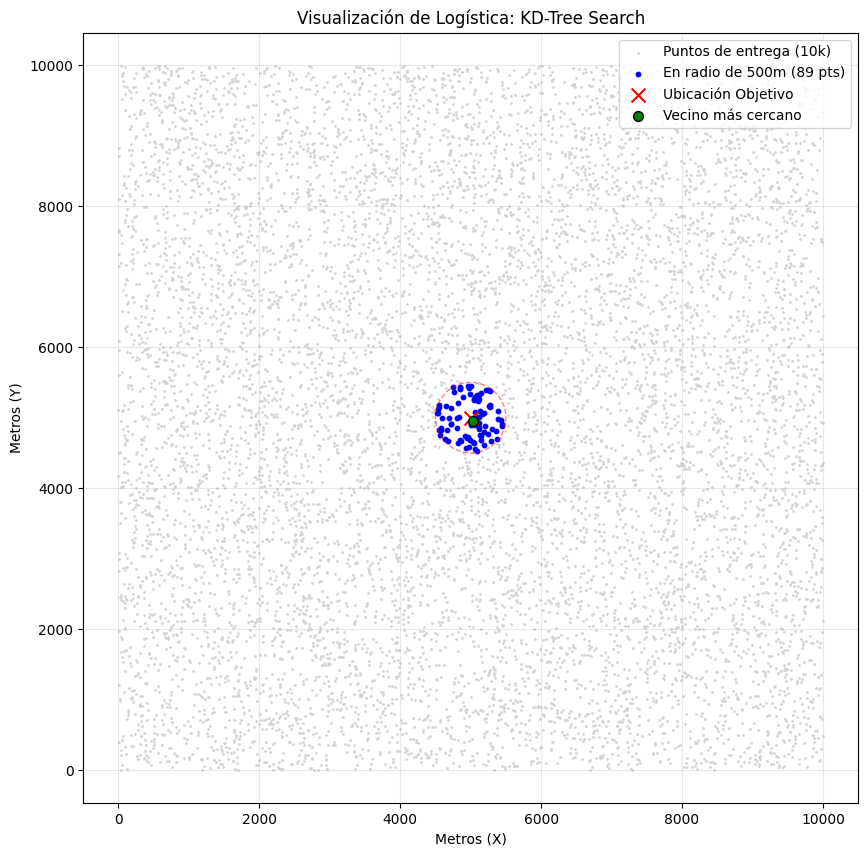

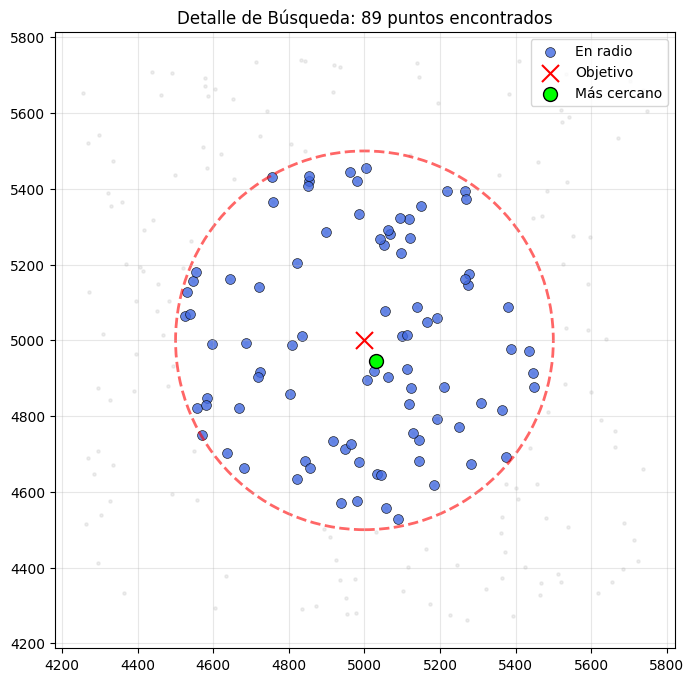

Resultados:
- Puntos encontrados en el radio: 89
- Punto más cercano: [5030.684634788309, 4946.682822273434]


In [24]:
import numpy as np
import matplotlib.pyplot as plt  #HECHO EN TOTALIDAD POR IA (GEMINI), NO HABIA TRABAJADO CON LIBRERIAS DE GRAFICAS NI SABIA COMO GENERARLAS.
import time

# --- 1. GENERACIÓN DE DATOS ESTATICOS ---
np.random.seed(42)  # Para que los puntos no cambien cada vez que corra la celda
num_puntos = 10000
# Simulamos una ciudad de 10000 x 10000 (coordenadas en metros)
puntos_entrega = np.random.uniform(0, 10000, size=(num_puntos, 2)).tolist()

# --- 2. CONSTRUCCIÓN DEL ÁRBOL ---
print("Construyendo el Arbol-KD con 10,000 puntos...")
inicio_build = time.time()
arbol = ArbolKD(puntos_entrega)
fin_build = time.time()
print(f"Árbol construido en {fin_build - inicio_build:.4f} segundos.\n")

# --- 3. CONFIGURACIÓN DE LA BÚSQUEDA ---
punto_objetivo = [5000, 5000]  # El centro de la ciudad
radio_busqueda = 500           # 500 metros

# --- 4. EJECUCIÓN DE LAS BÚSQUEDAS ---
# Búsqueda por Radio (KD-Tree)
puntos_en_radio = arbol.buscarPorRadio(punto_objetivo, radio_busqueda)

# Vecino más cercano (KD-Tree)
mas_cercano = arbol.buscarMasCercano(punto_objetivo)

# --- 5. VERIFICACIÓN VISUAL ---
plt.figure(figsize=(10, 10))

# Extraer coordenadas para graficar rápido
pts_x, pts_y = zip(*puntos_entrega)
plt.scatter(pts_x, pts_y, s=1, c='lightgray', label='Puntos de entrega (10k)')

# Graficar puntos encontrados dentro del radio
if puntos_en_radio:
    pr_x, pr_y = zip(*puntos_en_radio)
    plt.scatter(pr_x, pr_y, s=10, c='blue', label=f'En radio de {radio_busqueda}m ({len(puntos_en_radio)} pts)')

# Graficar el punto objetivo y su radio
plt.scatter(punto_objetivo[0], punto_objetivo[1], c='red', marker='x', s=100, label='Ubicación Objetivo')
circulo = plt.Circle((punto_objetivo[0], punto_objetivo[1]), radio_busqueda, color='red', fill=False, linestyle='--', alpha=0.5)
plt.gca().add_patch(circulo)

# Graficar el vecino más cercano
if mas_cercano:
    plt.scatter(mas_cercano[0], mas_cercano[1], c='green', s=50, edgecolors='black', label='Vecino más cercano')
    # Dibujar una línea al vecino más cercano
    plt.plot([punto_objetivo[0], mas_cercano[0]], [punto_objetivo[1], mas_cercano[1]], c='green', linestyle='-', alpha=0.6)

plt.title("Visualización de Logística: KD-Tree Search")
plt.xlabel("Metros (X)")
plt.ylabel("Metros (Y)")
plt.legend(loc='upper right')
plt.axis('equal') # Importante para que el círculo no parezca un óvalo
plt.grid(True, alpha=0.3)
plt.show()

#Grafica con zoom

import numpy as np # Asegúrate de tener esta línea al inicio de tu código

plt.figure(figsize=(8, 8))

# Convertimos a arreglos de numpy para poder hacer comparaciones matemáticas
arr_x = np.array(pts_x)
arr_y = np.array(pts_y)

# 1. Filtramos los puntos que están cerca del área para el zoom
margen_zoom = radio_busqueda * 1.5
filtro = (arr_x > punto_objetivo[0] - margen_zoom) & \
         (arr_x < punto_objetivo[0] + margen_zoom) & \
         (arr_y > punto_objetivo[1] - margen_zoom) & \
         (arr_y < punto_objetivo[1] + margen_zoom)

# Graficamos solo los puntos que pasan el filtro (el fondo del zoom)
plt.scatter(arr_x[filtro], arr_y[filtro], s=5, c='lightgray', alpha=0.4)

# 2. Puntos dentro del radio
if puntos_en_radio:
    pr_x, pr_y = zip(*puntos_en_radio)
    plt.scatter(pr_x, pr_y, s=50, c='royalblue', alpha=0.8, edgecolors='black', linewidth=0.5, label='En radio')

# 3. Punto objetivo y círculo
plt.scatter(punto_objetivo[0], punto_objetivo[1], c='red', marker='x', s=150, label='Objetivo', zorder=5)
circulo = plt.Circle((punto_objetivo[0], punto_objetivo[1]), radio_busqueda, color='red', fill=False, linestyle='--', alpha=0.6, linewidth=2)
plt.gca().add_patch(circulo)

# 4. Vecino más cercano
if mas_cercano:
    plt.scatter(mas_cercano[0], mas_cercano[1], c='lime', s=100, edgecolors='black', label='Más cercano', zorder=6)

# --- ESCALA ---
plt.xlim(punto_objetivo[0] - margen_zoom, punto_objetivo[0] + margen_zoom)
plt.ylim(punto_objetivo[1] - margen_zoom, punto_objetivo[1] + margen_zoom)

plt.title(f"Detalle de Búsqueda: {len(puntos_en_radio)} puntos encontrados")
plt.legend(loc='upper right')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Resultados:")
print(f"- Puntos encontrados en el radio: {len(puntos_en_radio)}")
print(f"- Punto más cercano: {mas_cercano}")

## 4. Análisis de Rendimiento: KD-Tree vs. Fuerza Bruta
Para la comparación entre ambas estructuras de datos, se realiza una búsqueda 100 veces en ambos métodos y se promedia el tiempo de cada ejecución. Se realiza dicho proceso con 7 cantidades diferentes de datos, aumentandola gradualmente, para mirar cómo se comporta cuando la cantidad de datos es pequeña (100) y cómo cambia cuando va aumentando (hasta llegar a 10000).



#CODIGO DEL ANALISIS: ANALISIS NUMERICO Y GRAFICA.

Resultado para 100 puntos:
  Vecino Cercano -- ArbolKD: 0.000035s -- Fuerza Bruta: 0.000053s
  Busqueda Radio -- ArbolKD: 0.000005s -- Fuerza Bruta: 0.000050s
Resultado para 500 puntos:
  Vecino Cercano -- ArbolKD: 0.000039s -- Fuerza Bruta: 0.000295s
  Busqueda Radio -- ArbolKD: 0.000009s -- Fuerza Bruta: 0.000272s
Resultado para 1000 puntos:
  Vecino Cercano -- ArbolKD: 0.000058s -- Fuerza Bruta: 0.000509s
  Busqueda Radio -- ArbolKD: 0.000016s -- Fuerza Bruta: 0.000503s
Resultado para 2500 puntos:
  Vecino Cercano -- ArbolKD: 0.000052s -- Fuerza Bruta: 0.001576s
  Busqueda Radio -- ArbolKD: 0.000018s -- Fuerza Bruta: 0.001541s
Resultado para 5000 puntos:
  Vecino Cercano -- ArbolKD: 0.000028s -- Fuerza Bruta: 0.004797s
  Busqueda Radio -- ArbolKD: 0.000060s -- Fuerza Bruta: 0.004607s
Resultado para 7500 puntos:
  Vecino Cercano -- ArbolKD: 0.000014s -- Fuerza Bruta: 0.007913s
  Busqueda Radio -- ArbolKD: 0.000119s -- Fuerza Bruta: 0.006529s
Resultado para 10000 puntos:
  Vecino Cerc

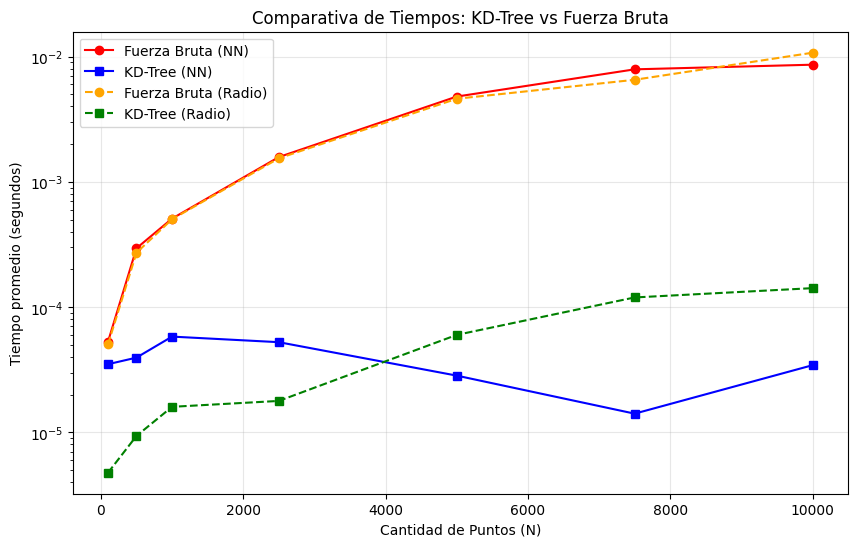

In [ ]:
import time

"""FUNCION buscar_mas_cercano_fuerza_bruta(): Ingresamos como parametro todos los puntos, y el punto al cual queremos conocerle su más cercano.
Lo que hace el algoritmo es calcular la distancia euclidiana entre el punto objetivo y cada punto dentro del array. Debe pasar por todos los elementos del array obligatoriamente (costoso) """

def buscar_mas_cercano_fuerza_bruta(puntos, objetivo):
    mejor_punto = None
    mejor_distancia = float('inf')
    for p in puntos:
        dist = calcularDistancia(p, objetivo)
        if dist < mejor_distancia:
            mejor_distancia = dist
            mejor_punto = p
    return mejor_punto


"""FUNCION buscar_por_radio_fuerza_bruta(): Recibe como parametros la lista de puntos, el objetivo sobre el cual vamos a trazar el radio, y el radio de busqueda. Su funcionamiento es analogo al de buscar_mas_cercano,
evalua distancia entre el objetivo y cada punto dentro de la lista: si es menor que el radio que pasamos como parametro, lo ingresamos al array de puntos cercanos. De nuevo, como no se delimita de ninguna manera
a nivel espacial, es necesario recorrer todos los elementos del array (costoso).
"""

def buscar_por_radio_fuerza_bruta(puntos, objetivo, radio):
    cercanos = []
    for p in puntos:
        if calcularDistancia(p, objetivo) <= radio:
            cercanos.append(p)
    return cercanos



# Configuracion del experimento para el analisis
tamanos = [100, 500, 1000, 2500, 5000, 7500, 10000] #Arreglo de tamaños para ensayar ambas estructuras de datos en diferentes condiciones: con 100 puntos, 500 puntos, 1000 puntos, ..., 10000 puntos.
tiempos_kdtree = [] #arreglo para almacenar el tiempo asociado a cada cantidad de puntos. Importante para graficar.
tiempos_fuerza_bruta = [] ##arreglo para almacenar el tiempo asociado a cada cantidad de puntos. Importante para graficar al final
tiempos_kdtree_radio = [] #Arreglo para almacenar los tiempos asociados a encontrar los puntos a un radio dado, dentro de cada tamaño de datos (arbolKD).
tiempos_fb_radio = [] #Arreglo para almacenar los tiempos asociados a encontrar los puntos a un radio dado, dentro de cada tamaño de datos(con fuerza bruta).



for n in tamanos: #Para cada numero de datos, hacemos un slice de la lista anteriormente generada.
    # Usamos un subconjunto de los puntos de entrega generados anteriormente
    puntos_test = puntos_entrega[:n]
    arbol_test = ArbolKD(puntos_test) #Creamos el arbol con el numero de datos asociado
    objetivo_test = [5000, 5000]
    radio_test =500

    #MEDICION VECINO MAS CERCANO

    # Medimos el tiempo de busqueda con el arbol
    # Promediamos sobre 100 iteraciones para mayor precisión
    inicio = time.time()
    for _ in range(100):
        arbol_test.buscarMasCercano(objetivo_test)
    t_kd = (time.time() - inicio) / 100
    tiempos_kdtree.append(t_kd)

    # Medir tiempo en caso fuerza bruta. Promediamos tambien.
    inicio = time.time()
    for _ in range(100):
        buscar_mas_cercano_fuerza_bruta(puntos_test, objetivo_test)
    t_fb = (time.time() - inicio) / 100
    tiempos_fuerza_bruta.append(t_fb)

    #MEDICION PUNTOS ENCONTRADOS POR RADIO

    #Medimos el tiempo de busqueda por radio en cada caso, y se promedia el valor de 100 ejecuciones.

    inicio = time.time()
    for _ in range(100):
        arbol_test.buscarPorRadio(objetivo_test, radio_test)
    t_kd_r = (time.time() - inicio) / 100
    tiempos_kdtree_radio.append(t_kd_r)

    inicio = time.time()
    for _ in range(100):
        buscar_por_radio_fuerza_bruta(puntos_test, objetivo_test, radio_test)
    t_fb_r = (time.time() - inicio) / 100
    tiempos_fb_radio.append(t_fb_r)

    print("Resultado para " + str(n) + " puntos:")
    print(f"  Vecino Cercano -- ArbolKD: {t_kd:.6f}s -- Fuerza Bruta: {t_fb:.6f}s")
    print(f"  Busqueda Radio -- ArbolKD: {t_kd_r:.6f}s -- Fuerza Bruta: {t_fb_r:.6f}s")


#GRAFICAR RESULTADOS (HECHO POR GEMINI)

plt.figure(figsize=(10, 6))
plt.plot(tamanos, tiempos_fuerza_bruta, label='Fuerza Bruta (NN)', marker='o', color='red')
plt.plot(tamanos, tiempos_kdtree, label='KD-Tree (NN)', marker='s', color='blue')
plt.plot(tamanos, tiempos_fb_radio, label='Fuerza Bruta (Radio)', marker='o', color='orange', linestyle='--')
plt.plot(tamanos, tiempos_kdtree_radio, label='KD-Tree (Radio)', marker='s', color='green', linestyle='--')

plt.title("Comparativa de Tiempos: KD-Tree vs Fuerza Bruta")
plt.xlabel("Cantidad de Puntos (N)")
plt.ylabel("Tiempo promedio (segundos)")
plt.yscale('log') # Escala logarítmica para apreciar la diferencia
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5. ANALISIS Y CONCLUSIONES
Tras las pruebas realizadas podemos determinar que:

- **El Arbol KD demuestra su eficiencia desde escalas pequeñas**:


Podemos observar que el arbol KD se muestra superior incluso en escalas de datos pequeñas. Mientras que tiempo de búsqueda tanto por radio como por el más cercano se dispara en el caso de fuerza bruta, al pasar de **100 a 500**, el ArbolKD tiene un tiempo supremamente bajo y estable, tanto así que la gráfica tuvo que hacerse a este tipo de escalas ya que el cambio es casi imperceptible.

- **Escalabilidad**: La diferencia en rendimiento se marca muchísimo con el crecimiento del numero de puntos. El costo de búsqueda dentro de fuerza bruta es lineal: es necesario hacer una comparación con cada punto dentro del arreglo. Por otro lado, el **árbol KD** a través de esos descartes inteligentes por regiones, y esas subdivisiones para mapear en un hiperplano todos esos puntos que tenemos, logra reducir su costo computacional a **O(logN)**

- **Rendimiento de la división espacial:** En cantidades grandes de datos, el arbol puede descartar regiones inmensas del espacio con pocas comparaciones. Por eso, aunque aumentemos la escala del número de puntos, el tiempo que se toma encontrar un punto dentro de ese espacio no crece de la misma manera.




